In [1]:
import sys
print(sys.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]


In [2]:
import requests
import bs4
import pandas
import matplotlib
import seaborn
import scipy
import re
import time
import json

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
import requests

url = "https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName=Navi-Mumbai"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)
print("Response size:", len(response.text), "characters")

Status code: 200
Response size: 1155801 characters


In [4]:
# Extract all property URLs first
urls = re.findall(r'"url":"(https://www\.magicbricks\.com/propertyDetails/.*?)"', response.text)

print(f"Total listings found: {len(urls)}")
print("\nFirst 3 URLs:")
for url in urls[:3]:
    print(url)

Total listings found: 60

First 3 URLs:
https://www.magicbricks.com/propertyDetails/1-BHK-328-Sq-ft-Multistorey-Apartment-FOR-Sale-Panvel-in-Navi-Mumbai&id=4d423832373631363633
https://www.magicbricks.com/propertyDetails/3-BHK-1900-Sq-ft-Multistorey-Apartment-FOR-Sale-Kharghar-in-Navi-Mumbai&id=4d423835323039393239
https://www.magicbricks.com/propertyDetails/3-BHK-2000-Sq-ft-Multistorey-Apartment-FOR-Sale-Kharghar-in-Navi-Mumbai&id=4d423835323435393939


In [5]:
# We'll store each listing as a dictionary
listings = []

for url in urls:
    # Extract the property details part from the URL
    # Example: "4-BHK-1619-Sq-ft-Multistorey-Apartment-FOR-Sale-Ghansoli-in-Navi-Mumbai"
    match = re.search(
        r'propertyDetails/(\d+)-BHK-(\d+)-Sq-ft-[\w-]+-FOR-Sale-([\w]+)-in-Navi-Mumbai',
        url
    )
    
    if match:
        bhk      = int(match.group(1))   # e.g. 4
        area     = int(match.group(2))   # e.g. 1619
        locality = match.group(3)        # e.g. Ghansoli
        
        listings.append({
            "bhk"      : bhk,
            "area_sqft": area,
            "locality" : locality
        })

print(f"Successfully parsed: {len(listings)} listings")
print("\nFirst 5:")
for l in listings[:5]:
    print(l)

Successfully parsed: 56 listings

First 5:
{'bhk': 1, 'area_sqft': 328, 'locality': 'Panvel'}
{'bhk': 3, 'area_sqft': 1900, 'locality': 'Kharghar'}
{'bhk': 3, 'area_sqft': 2000, 'locality': 'Kharghar'}
{'bhk': 3, 'area_sqft': 1082, 'locality': 'Nerul'}
{'bhk': 3, 'area_sqft': 1197, 'locality': 'Nerul'}


In [6]:
import pandas as pd

# Convert our list of dictionaries into a DataFrame
df = pd.DataFrame(listings)

# Let's see what we have
print(df.shape)   # rows, columns
print()
df.head(10)       # first 10 rows

(56, 3)



,bhk,area_sqft,locality
0,1,328,Panvel
1,3,1900,Kharghar
2,3,2000,Kharghar
3,3,1082,Nerul
4,3,1197,Nerul
5,2,994,Ulwe
6,2,707,Kharghar
7,2,714,Airoli
8,4,1886,Juinagar
9,2,1250,Kharghar


In [7]:
# Get a summary of the entire DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   bhk        56 non-null     int64 
 1   area_sqft  56 non-null     int64 
 2   locality   56 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.4+ KB


In [8]:
# Each listing object starts with "price": and has "priceD" nearby
# Let's extract all priceD values and their surrounding context

matches = re.findall(
    r'"devName":"(.*?)".*?"price":(\d+).*?"priceD":"(.*?)".*?"seoDesc":"(.*?)"',
    response.text
)

print(f"Listings with full data: {len(matches)}")
print("\nFirst 3:")
for m in matches[:3]:
    print({
        "developer": m[0],
        "price_raw": m[1],
        "price_fmt": m[2],
        "description": m[3]
    })

Listings with full data: 30

First 3:
{'developer': 'Jindal Builder', 'price_raw': '4794000', 'price_fmt': '47.9 Lac', 'description': "The 1 BHK flat is available for sale in Panvel, Navi Mumbai.The flat is located in Jindal Air which is a 2 years old construction. There is a 1 covered parking space available within this 1 BHK apartment where you can easily park your vehicles. This mar '27 apartment in the Panvel is available for a price of ₹47.9 Lac. The date of possession of the flat stands at Mar '27. This is a RERA approved project and P52000054929 is the RERA number. Property rates in Jindal Air fall within ₹43 Lac - ₹47.9 Lac, with multiple 1 bhk flats options. "}
{'developer': 'Paradise Group', 'price_raw': '26624000', 'price_fmt': '2.66 Cr', 'description': "You can find this 3 BHK flat for sale in Kharghar, Navi Mumbai.It enjoys a prime location within Paradise Sai World Empire. This dec '29 apartment in the Kharghar is available for a price of ₹2.66 Cr. Dec '29 is the possessi

In [9]:
def extract_locality(desc):
    # Pattern 1: "in Ghansoli, Navi Mumbai"
    m = re.search(r'in\s+([\w\s]+),\s+Navi Mumbai', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 2: "prime location of Panvel" or "location of Kharghar"
    m = re.search(r'location of\s+([\w\s]+?)[,\.]', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 3: "Panvel, Navi Mumbai has"
    m = re.search(r'^([\w\s]+),\s+Navi Mumbai\s+has', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 4: "premium Kharghar locality"
    m = re.search(r'premium\s+([\w\s]+?)\s+locality', desc)
    if m:
        return m.group(1).strip()

    # Pattern 5: "4 BHK flat in Panvel is"
    m = re.search(r'\d+\s+BHK\s+\w+\s+in\s+([\w\s]+?)\s+is', desc)
    if m:
        return m.group(1).strip()

    # Pattern 6: "apartment in Seawoods to"
    m = re.search(r'apartment in\s+([\w\s]+?)\s+to', desc)
    if m:
        return m.group(1).strip()

    return None

# Test again
for m in matches:
    desc = m[3]
    locality = extract_locality(desc)
    display = locality if locality else "NOT FOUND"
    print(f"{display:20} | {desc[:60]}")

Panvel               | The 1 BHK flat is available for sale in Panvel, Navi Mumbai.
Kharghar             | You can find this 3 BHK flat for sale in Kharghar, Navi Mumb
Kharghar             | This 3 BHK flat is in Kharghar, Navi Mumbai.The property is 
NOT FOUND            | The 3 BHK apartment is located in a well-connected area of S
Nerul                | This spacious 3 BHK apartment can be found for sale in Nerul
Nerul                | 3 BHK flat available for sale in Navi Mumbai in the prime lo
NOT FOUND            | The 2 BHK apartment is immediately available for sale in Ulw
NOT FOUND            | The 2 BHK apartment is located in a well-connected area of K
Airoli               | Now available for sale: this 2 BHK apartment in Airoli, Navi
Juinagar             | A beautiful 4 BHK flat in Juinagar is currently available fo
Kharghar             | The 2 BHK flat is available for sale in Kharghar, Navi Mumba
Kharghar             | Kharghar, Navi Mumbai has a 3 BHK apartment for sale 

In [10]:
def parse_listing(block):
    """Extract all fields from one listing's JSON block"""
    
    # Price
    price_match = re.search(r'"price":(\d+)', block)
    price = int(price_match.group(1)) if price_match else None
    
    # Formatted price
    price_fmt_match = re.search(r'"priceD":"(.*?)"', block)
    price_fmt = price_fmt_match.group(1) if price_fmt_match else None
    
    # Developer
    dev_match = re.search(r'"devName":"(.*?)"', block)
    developer = dev_match.group(1) if dev_match else None
    
    # Description
    desc_match = re.search(r'"seoDesc":"(.*?)"', block)
    desc = desc_match.group(1) if desc_match else ""
    
    # BHK from description
    bhk_match = re.search(r'(\d+)\s+BHK', desc)
    bhk = int(bhk_match.group(1)) if bhk_match else None
    
    # Locality from description
    locality = extract_locality(desc)
    
    # Area sqft from description e.g. "carpet area 360 sqft"
    area_match = re.search(r'carpet area\s+(\d+)\s+sqft', desc)
    area = int(area_match.group(1)) if area_match else None
    
    # Project name from description e.g. "located in Siddhivinayak Apartment"
    project_match = re.search(r'located in\s+(.*?)[,\.]', desc)
    project = project_match.group(1).strip() if project_match else None
    
    # Possession date e.g. "dec '31" or "ready to move"
    possess_match = re.search(r'(ready to move|[\w]+\s+\'\d+)', desc, re.IGNORECASE)
    possession = possess_match.group(1).strip() if possess_match else None
    
    # Landmarks - extract by category code
    landmarks = re.findall(r'"(\d+)\|([^"]+)"', block)
    
    railway  = [name for code, name in landmarks if code == "19210"]
    hospital = [name for code, name in landmarks if code == "19203"]
    market   = [name for code, name in landmarks if code == "19206"]
    
    # Take first of each (nearest one)
    nearest_railway  = railway[0]  if railway  else None
    nearest_hospital = hospital[0] if hospital else None
    nearest_market   = market[0]   if market   else None
    
    return {
        "bhk"             : bhk,
        "price"           : price,
        "price_fmt"       : price_fmt,
        "locality"        : locality,
        "developer"       : developer,
        "project"         : project,
        "area_sqft"       : area,
        "possession"      : possession,
        "nearest_railway" : nearest_railway,
        "nearest_hospital": nearest_hospital,
        "nearest_market"  : nearest_market
    }

print("Function defined successfully!")

Function defined successfully!


In [11]:
all_blocks = []

for page in range(1, 51):  # Pages 1 to 50
    
    url = f"https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName=Navi-Mumbai&page={page}"
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        # Extract individual listing blocks
        # Each block starts with "devName" and ends after "seoDesc"
        blocks = re.findall(
            r'\{[^{}]*"devName":".*?"seoDesc":".*?"\}',
            response.text,
            re.DOTALL
        )
        all_blocks.extend(blocks)
        print(f"Page {page}: {len(blocks)} blocks (total: {len(all_blocks)})")
    else:
        print(f"Page {page}: Failed with status {response.status_code}")
    
    time.sleep(2)

print(f"\nDone! Total blocks collected: {len(all_blocks)}")

Page 1: 28 blocks (total: 28)
Page 2: 24 blocks (total: 52)
Page 3: 22 blocks (total: 74)
Page 4: 24 blocks (total: 98)
Page 5: 22 blocks (total: 120)
Page 6: 23 blocks (total: 143)
Page 7: 14 blocks (total: 157)
Page 8: 18 blocks (total: 175)
Page 9: 26 blocks (total: 201)
Page 10: 22 blocks (total: 223)
Page 11: 25 blocks (total: 248)
Page 12: 21 blocks (total: 269)
Page 13: 28 blocks (total: 297)
Page 14: 24 blocks (total: 321)
Page 15: 20 blocks (total: 341)
Page 16: 25 blocks (total: 366)
Page 17: 28 blocks (total: 394)
Page 18: 20 blocks (total: 414)
Page 19: 23 blocks (total: 437)
Page 20: 27 blocks (total: 464)
Page 21: 5 blocks (total: 469)
Page 22: 3 blocks (total: 472)
Page 23: 30 blocks (total: 502)
Page 24: 27 blocks (total: 529)
Page 25: 29 blocks (total: 558)
Page 26: 30 blocks (total: 588)
Page 27: 30 blocks (total: 618)
Page 28: 29 blocks (total: 647)
Page 29: 27 blocks (total: 674)
Page 30: 25 blocks (total: 699)
Page 31: 17 blocks (total: 716)
Page 32: 17 blocks (tot

In [12]:
parsed_listings = []

for block in all_blocks:
    listing = parse_listing(block)
    parsed_listings.append(listing)

df_rich = pd.DataFrame(parsed_listings)

print(f"Total rows: {len(df_rich)}")
print(f"\nMissing values per column:")
print(df_rich.isna().sum())
print(f"\nSample:")
print(df_rich.head(3).to_string())

Total rows: 1205

Missing values per column:
bhk                   1
price                 0
price_fmt             0
locality             63
developer             0
project             784
area_sqft           456
possession           66
nearest_railway     301
nearest_hospital    310
nearest_market      488
dtype: int64

Sample:
   bhk     price price_fmt  locality       developer                                         project  area_sqft possession                   nearest_railway            nearest_hospital     nearest_market
0  1.0   4794000  47.9 Lac    Panvel  Jindal Builder  Jindal Air which is a 2 years old construction        NaN    mar '27        Mansarovar Railway Station           New City Hospital     Mahalaxmi Mall
1  3.0  26624000   2.66 Cr  Kharghar  Paradise Group                                            None        NaN    dec '29  Pethpada Metro Station|5 minutes            Dolphin Hospital         Prime Mall
2  3.0  27500000   2.75 Cr  Kharghar  Paradise Group     

In [13]:
# Step 1: Drop rows where critical fields are missing
df_clean = df_rich.dropna(subset=["locality", "bhk", "price"])

print(f"After dropping missing locality/bhk/price: {len(df_clean)} rows")

# Step 2: Remove duplicate listings (same price + locality + bhk)
df_clean = df_clean.drop_duplicates(subset=["price", "locality", "bhk"])

print(f"After removing duplicates: {len(df_clean)} rows")

# Step 3: Convert bhk to integer (it's currently float because of the one missing value)
df_clean["bhk"] = df_clean["bhk"].astype(int)

# Step 4: Add price per sqft only where area is available
df_clean_with_area = df_clean.dropna(subset=["area_sqft"]).copy()
df_clean_with_area["price_per_sqft"] = (df_clean_with_area["price"] / df_clean_with_area["area_sqft"]).round(0)

print(f"Rows with area data for price/sqft analysis: {len(df_clean_with_area)}")

# Step 5: Save both versions
df_clean.to_csv("navi_mumbai_full.csv", index=False)
df_clean_with_area.to_csv("navi_mumbai_with_area.csv", index=False)

print("\nBoth files saved!")

After dropping missing locality/bhk/price: 1142 rows
After removing duplicates: 771 rows
Rows with area data for price/sqft analysis: 455

Both files saved!


In [14]:
# Keep only localities with 10+ listings for reliable analysis
locality_counts = df_clean["locality"].value_counts()
valid_localities = locality_counts[locality_counts >= 10].index.tolist()

print(f"Localities with 10+ listings: {len(valid_localities)}")
print(valid_localities)

# Filter both DataFrames
df_main = df_clean[df_clean["locality"].isin(valid_localities)].copy()
df_area = df_clean_with_area[df_clean_with_area["locality"].isin(valid_localities)].copy()

print(f"\nRows in main dataset: {len(df_main)}")
print(f"Rows with area data: {len(df_area)}")

Localities with 10+ listings: 16
['Panvel', 'Kharghar', 'Taloja', 'Ulwe', 'New Panvel', 'Kamothe', 'Roadpali', 'Karanjade', 'Ghansoli', 'Nerul', 'Airoli', 'Kopar Khairane', 'Kalamboli', 'Taloja Panchanand', 'Sanpada', 'Dronagiri']

Rows in main dataset: 641
Rows with area data: 386


In [15]:
# Average price per sqft by locality - sorted cheapest first
price_analysis = df_area.groupby("locality")["price_per_sqft"].agg(["mean", "median", "count"]).round(0)
price_analysis.columns = ["avg_price_sqft", "median_price_sqft", "listings"]
price_analysis = price_analysis.sort_values("median_price_sqft")

print("Price per Sq Ft by Locality (cheapest first):")
print()
print(f"{'Locality':<20} {'Avg ₹/sqft':>12} {'Median ₹/sqft':>15} {'Listings':>10}")
print("-" * 60)
for locality, row in price_analysis.iterrows():
    print(f"{locality:<20} {row['avg_price_sqft']:>12,.0f} {row['median_price_sqft']:>15,.0f} {row['listings']:>10.0f}")

Price per Sq Ft by Locality (cheapest first):

Locality               Avg ₹/sqft   Median ₹/sqft   Listings
------------------------------------------------------------
New Panvel                  9,374           8,000         27
Taloja                      8,137           8,004         53
Taloja Panchanand           8,567           8,173          9
Panvel                     10,955           9,808         77
Karanjade                  10,264           9,815         15
Kalamboli                  11,714          10,244          8
Dronagiri                  12,126          10,976          7
Roadpali                   11,858          11,102         22
Ulwe                       13,616          12,011         44
Kamothe                    12,656          12,222         21
Kharghar                   14,067          13,131         51
Ghansoli                   19,739          18,352         14
Kopar Khairane             20,038          19,084         14
Airoli                     20,811     

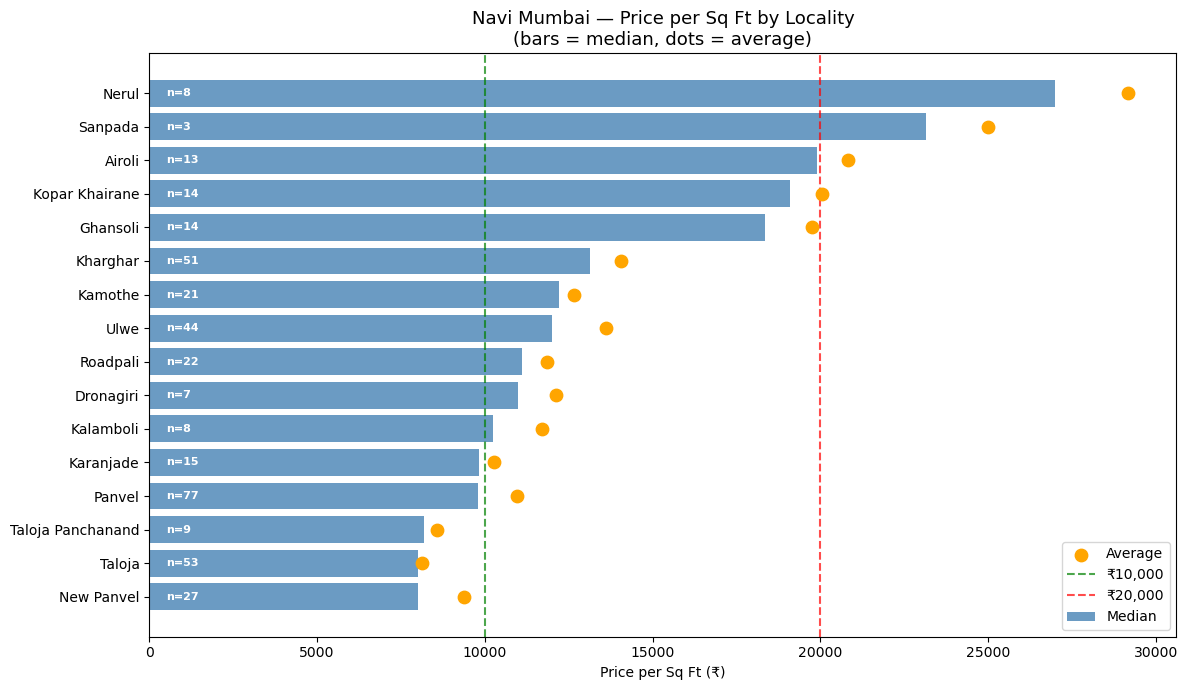

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by median price for clean visualization
plot_data = price_analysis.reset_index().sort_values("median_price_sqft")

plt.figure(figsize=(12, 7))

# Main bars - median price
bars = plt.barh(plot_data["locality"], plot_data["median_price_sqft"], 
                color="steelblue", alpha=0.8, label="Median")

# Overlay dots - average price
plt.scatter(plot_data["avg_price_sqft"], plot_data["locality"], 
            color="orange", zorder=5, s=80, label="Average")

# Add listing count as text on each bar
for i, (_, row) in enumerate(plot_data.iterrows()):
    plt.text(500, i, f"n={row['listings']:.0f}", 
             va="center", fontsize=8, color="white", fontweight="bold")

# Reference lines
plt.axvline(x=10000, color="green", linestyle="--", alpha=0.7, label="₹10,000")
plt.axvline(x=20000, color="red", linestyle="--", alpha=0.7, label="₹20,000")

plt.xlabel("Price per Sq Ft (₹)")
plt.title("Navi Mumbai — Price per Sq Ft by Locality\n(bars = median, dots = average)", 
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Average price by locality AND BHK type
bhk_analysis = df_main[df_main["bhk"].isin([1, 2, 3])].groupby(
    ["locality", "bhk"]
)["price"].median().round(0) / 100000  # Convert to Lakhs

# Reshape into a table: localities as rows, BHK as columns
bhk_table = bhk_analysis.unstack("bhk")
bhk_table.columns = ["1 BHK", "2 BHK", "3 BHK"]

# Sort by 2 BHK price
bhk_table = bhk_table.sort_values("2 BHK")

print("Median Price by Locality and BHK (in Lakhs):")
print()
print(f"{'Locality':<20} {'1 BHK':>10} {'2 BHK':>10} {'3 BHK':>10}")
print("-" * 52)
for locality, row in bhk_table.iterrows():
    bhk1 = f"₹{row['1 BHK']:.0f}L" if not pd.isna(row['1 BHK']) else "N/A"
    bhk2 = f"₹{row['2 BHK']:.0f}L" if not pd.isna(row['2 BHK']) else "N/A"
    bhk3 = f"₹{row['3 BHK']:.0f}L" if not pd.isna(row['3 BHK']) else "N/A"
    print(f"{locality:<20} {bhk1:>10} {bhk2:>10} {bhk3:>10}")

Median Price by Locality and BHK (in Lakhs):

Locality                  1 BHK      2 BHK      3 BHK
----------------------------------------------------
Taloja                     ₹39L       ₹56L      ₹125L
New Panvel                 ₹40L       ₹60L      ₹135L
Taloja Panchanand          ₹37L       ₹70L        N/A
Panvel                     ₹47L       ₹72L      ₹150L
Karanjade                  ₹44L       ₹75L        N/A
Kalamboli                  ₹49L       ₹80L        N/A
Kamothe                    ₹61L       ₹86L      ₹130L
Roadpali                   ₹54L       ₹87L      ₹166L
Dronagiri                  ₹43L       ₹88L      ₹142L
Ulwe                       ₹52L       ₹96L      ₹165L
Kharghar                   ₹55L      ₹105L      ₹178L
Kopar Khairane             ₹90L      ₹125L      ₹220L
Ghansoli                   ₹82L      ₹135L      ₹277L
Sanpada                    ₹63L      ₹173L      ₹375L
Airoli                     ₹78L      ₹175L      ₹205L
Nerul                      ₹68L      

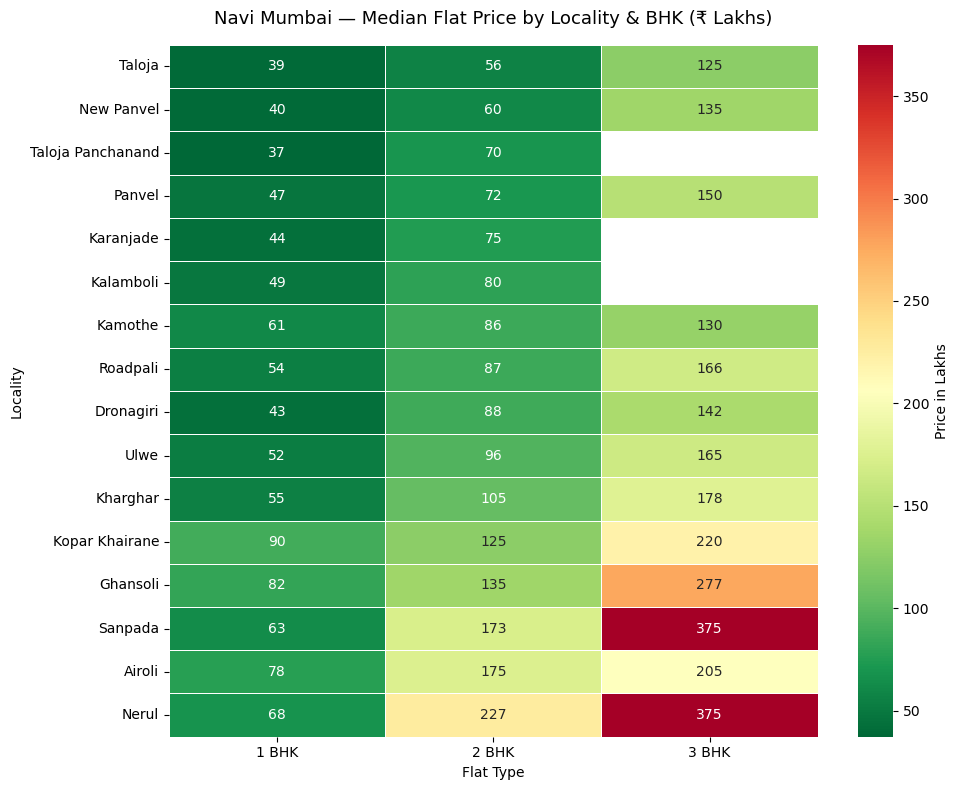

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    bhk_table,
    annot=True,           # Show numbers inside cells
    fmt=".0f",            # No decimal places
    cmap="RdYlGn_r",      # Red = expensive, Green = affordable
    linewidths=0.5,       # Grid lines between cells
    cbar_kws={"label": "Price in Lakhs"}
)

plt.title("Navi Mumbai — Median Flat Price by Locality & BHK (₹ Lakhs)", 
          fontsize=13, pad=15)
plt.xlabel("Flat Type")
plt.ylabel("Locality")
plt.tight_layout()
plt.show()

In [19]:
mumbai_url = "https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName=Mumbai"

response_mumbai = requests.get(mumbai_url, headers=headers)

print("Status code:", response_mumbai.status_code)
print("Response size:", len(response_mumbai.text), "characters")

# Check if same block structure exists
test_blocks = re.findall(
    r'\{[^{}]*"devName":".*?"seoDesc":".*?"\}',
    response_mumbai.text,
    re.DOTALL
)
print(f"Blocks found on page 1: {len(test_blocks)}")

Status code: 200
Response size: 1103169 characters
Blocks found on page 1: 29


In [21]:
all_blocks_combined = []

cities = {
    "Navi-Mumbai": "Navi Mumbai",
    "Mumbai": "Mumbai"
}

for city_param, city_name in cities.items():
    print(f"\nScraping {city_name}...")
    
    for page in range(1, 51):
        url = f"https://www.magicbricks.com/property-for-sale/residential-real-estate?proptype=Multistorey-Apartment,Builder-Floor-Apartment,Penthouse,Studio-Apartment&cityName={city_param}&page={page}"
        
        response = requests.get(url, headers=headers)
        
        if response.status_code == 200:
            blocks = re.findall(
                r'\{[^{}]*"devName":".*?"seoDesc":".*?"\}',
                response.text,
                re.DOTALL
            )
            
            # Tag each block with city before storing
            for block in blocks:
                all_blocks_combined.append({
                    "city" : city_name,
                    "block": block
                })
            
            print(f"  Page {page}: {len(blocks)} blocks (total: {len(all_blocks_combined)})")
        else:
            print(f"  Page {page}: Failed with status {response.status_code}")
        
        time.sleep(2)

print(f"\nDone! Total blocks: {len(all_blocks_combined)}")


Scraping Navi Mumbai...
  Page 1: 28 blocks (total: 28)
  Page 2: 24 blocks (total: 52)
  Page 3: 22 blocks (total: 74)
  Page 4: 24 blocks (total: 98)
  Page 5: 22 blocks (total: 120)
  Page 6: 23 blocks (total: 143)
  Page 7: 14 blocks (total: 157)
  Page 8: 18 blocks (total: 175)
  Page 9: 26 blocks (total: 201)
  Page 10: 22 blocks (total: 223)
  Page 11: 25 blocks (total: 248)
  Page 12: 21 blocks (total: 269)
  Page 13: 28 blocks (total: 297)
  Page 14: 24 blocks (total: 321)
  Page 15: 20 blocks (total: 341)
  Page 16: 25 blocks (total: 366)
  Page 17: 28 blocks (total: 394)
  Page 18: 20 blocks (total: 414)
  Page 19: 23 blocks (total: 437)
  Page 20: 27 blocks (total: 464)
  Page 21: 5 blocks (total: 469)
  Page 22: 3 blocks (total: 472)
  Page 23: 30 blocks (total: 502)
  Page 24: 27 blocks (total: 529)
  Page 25: 29 blocks (total: 558)
  Page 26: 30 blocks (total: 588)
  Page 27: 30 blocks (total: 618)
  Page 28: 29 blocks (total: 647)
  Page 29: 27 blocks (total: 674)
  Pa

In [22]:
def extract_locality(desc):
    # Pattern 1: "in Ghansoli, Navi Mumbai" OR "in Bandra East, Mumbai"
    m = re.search(r'in\s+([\w\s]+),\s+(Navi Mumbai|Mumbai)', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 2: "prime location of Panvel" or "area of Mahalakshmi"
    m = re.search(r'(?:location|area) of\s+([\w\s]+?)[,\.]', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 3: "Panvel, Navi Mumbai has" OR "Borivali East, Mumbai has"
    m = re.search(r'^([\w\s]+),\s+(?:Navi Mumbai|Mumbai)\s+has', desc)
    if m:
        return m.group(1).strip()
    
    # Pattern 4: "premium Kharghar locality"
    m = re.search(r'premium\s+([\w\s]+?)\s+locality', desc)
    if m:
        return m.group(1).strip()

    # Pattern 5: "4 BHK flat in Panvel is" OR "4 BHK apartment in Kandivali West"
    m = re.search(r'\d+\s+BHK\s+\w+\s+(?:is\s+)?(?:immediately\s+)?(?:available\s+)?(?:for\s+sale\s+)?in\s+([\w\s]+?)(?:\.|,|\s+is|\s+has|\s+This)', desc)
    if m:
        return m.group(1).strip()

    # Pattern 6: "apartment in Seawoods to"
    m = re.search(r'(?:flat|apartment|residence)\s+in\s+([\w\s]+?)\s+to', desc)
    if m:
        return m.group(1).strip()

    # Pattern 7: "for sale in Kandivali West.This"
    m = re.search(r'for sale in\s+([\w\s]+?)[\.,$]', desc)
    if m:
        return m.group(1).strip()

    # Pattern 8: "Now available for sale: this 3 BHK apartment in Goregaon West, Mumbai"
    m = re.search(r'this\s+\d+\s+BHK\s+\w+\s+in\s+([\w\s]+?)(?:,|\.|$)', desc)
    if m:
        return m.group(1).strip()

    return None

print("Function updated!")

Function updated!


In [23]:
all_listings = []

for item in all_blocks_combined:
    city  = item["city"]
    block = item["block"]
    
    listing = parse_listing(block)
    listing["city"] = city
    
    all_listings.append(listing)

df_combined = pd.DataFrame(all_listings)

# Clean - drop missing critical fields
df_combined = df_combined.dropna(subset=["locality", "bhk", "price"])

# Remove duplicates
df_combined = df_combined.drop_duplicates(subset=["price", "locality", "bhk"])

# Convert bhk to int
df_combined["bhk"] = df_combined["bhk"].astype(int)

print(f"Total clean listings: {len(df_combined)}")
print(f"\nBy city:")
print(df_combined["city"].value_counts())
print(f"\nTop 10 localities overall:")
print(df_combined["locality"].value_counts().head(10))

Total clean listings: 1873

By city:
city
Mumbai         1049
Navi Mumbai     824
Name: count, dtype: int64

Top 10 localities overall:
locality
Panvel           134
Kharghar          96
Ulwe              73
Taloja            71
New Panvel        49
Andheri West      47
Mulund West       40
Goregaon West     36
Andheri East      35
Kamothe           34
Name: count, dtype: int64


In [24]:
# Save master dataset
df_combined.to_csv("mumbai_realestate_master.csv", index=False)

# Add price per sqft where area is available
df_with_area = df_combined.dropna(subset=["area_sqft"]).copy()
df_with_area["price_per_sqft"] = (df_with_area["price"] / df_with_area["area_sqft"]).round(0)

print(f"Master dataset saved: {len(df_combined)} listings")
print(f"Listings with area data: {len(df_with_area)}")
print(f"\nColumns in dataset:")
for col in df_combined.columns:
    non_null = df_combined[col].notna().sum()
    pct = (non_null / len(df_combined) * 100).round(1)
    print(f"  {col:<20} {non_null:>5} non-null ({pct}%)")

Master dataset saved: 1873 listings
Listings with area data: 984

Columns in dataset:
  bhk                   1873 non-null (100.0%)
  price                 1873 non-null (100.0%)
  price_fmt             1873 non-null (100.0%)
  locality              1873 non-null (100.0%)
  developer             1873 non-null (100.0%)
  project                624 non-null (33.3%)
  area_sqft              984 non-null (52.5%)
  possession            1803 non-null (96.3%)
  nearest_railway       1420 non-null (75.8%)
  nearest_hospital      1480 non-null (79.0%)
  nearest_market        1264 non-null (67.5%)
  city                  1873 non-null (100.0%)


In [25]:
app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Mumbai Real Estate Explorer",
    layout="wide"
)

@st.cache_data(ttl=0)
def load_data():
    df = pd.read_csv("mumbai_realestate_master.csv")
    df_area = df.dropna(subset=["area_sqft"]).copy()
    df_area["price_per_sqft"] = (df_area["price"] / df_area["area_sqft"]).round(0)
    return df, df_area

df, df_area = load_data()

st.title("Mumbai & Navi Mumbai Real Estate Explorer")
st.caption("Data scraped from MagicBricks — 1,859 listings across Mumbai & Navi Mumbai")
st.markdown("---")

col1, col2, col3 = st.columns(3)

with col1:
    city_filter = st.selectbox("Select City", ["Both", "Mumbai", "Navi Mumbai"])

with col2:
    if city_filter == "Both":
        available_localities = sorted(df["locality"].unique())
    else:
        available_localities = sorted(df[df["city"] == city_filter]["locality"].unique())
    locality = st.selectbox("Select Locality", ["All"] + available_localities)

with col3:
    bhk_filter = st.multiselect("BHK Type", options=[1, 2, 3, 4, 5], default=[1, 2, 3])

filtered = df.copy()
filtered_area = df_area.copy()

if city_filter != "Both":
    filtered = filtered[filtered["city"] == city_filter]
    filtered_area = filtered_area[filtered_area["city"] == city_filter]

if locality != "All":
    filtered = filtered[filtered["locality"] == locality]
    filtered_area = filtered_area[filtered_area["locality"] == locality]

if bhk_filter:
    filtered = filtered[filtered["bhk"].isin(bhk_filter)]
    filtered_area = filtered_area[filtered_area["bhk"].isin(bhk_filter)]

st.markdown("---")

if len(filtered) == 0:
    st.warning("No listings found for selected filters.")
else:
    m1, m2, m3, m4 = st.columns(4)

    with m1:
        st.metric("Total Listings", len(filtered))
    with m2:
        st.metric("Median Price", f"Rs {filtered['price'].median()/100000:.0f}L")
    with m3:
        st.metric("Cheapest", f"Rs {filtered['price'].min()/100000:.0f}L")
    with m4:
        st.metric("Most Expensive", f"Rs {filtered['price'].max()/100000:.0f}L")

    st.markdown("---")

    left, right = st.columns(2)

    with left:
        st.subheader("Price by BHK Type")
        bhk_prices = filtered.groupby("bhk")["price"].median() / 100000
        bhk_prices = bhk_prices.reset_index()
        bhk_prices.columns = ["BHK", "Median Price (Lakhs)"]

        fig1, ax1 = plt.subplots(figsize=(6, 4))
        ax1.bar(
            bhk_prices["BHK"].astype(str) + " BHK",
            bhk_prices["Median Price (Lakhs)"],
            color="steelblue"
        )
        ax1.set_ylabel("Median Price (Rs Lakhs)")
        ax1.set_title("Median Price by BHK")
        plt.tight_layout()
        st.pyplot(fig1)
        plt.close()

    with right:
        st.subheader("Price Distribution")

        price_data = filtered["price"] / 100000
        cap = 1000
        capped = price_data[price_data <= cap]
        excluded = len(price_data) - len(capped)

        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.hist(capped, bins=30, color="steelblue", edgecolor="white")
        ax2.set_xlabel("Price (Rs Lakhs)")
        ax2.set_ylabel("Number of Listings")
        ax2.set_title(f"Price Distribution (below Rs {cap}L)")
        if excluded > 0:
            ax2.text(0.98, 0.95, f"{excluded} listings above Rs {cap}L not shown",
                     transform=ax2.transAxes, ha="right", va="top",
                     fontsize=7, color="gray")
        plt.tight_layout()
        st.pyplot(fig2)
        plt.close()

    st.markdown("---")

    st.subheader("Price per Sq Ft by Locality")

    if len(filtered_area) == 0:
        st.info("Area data not available for this selection. Price per sq ft cannot be calculated.")
    else:
        ppsf = filtered_area.groupby("locality")["price_per_sqft"].agg(
            Listings="count",
            Avg_Rs_sqft="mean",
            Median_Rs_sqft="median"
        ).round(0).reset_index()

        ppsf = ppsf.sort_values("Median_Rs_sqft")
        ppsf.columns = ["Locality", "Listings", "Avg Rs/sqft", "Median Rs/sqft"]

        st.dataframe(
            ppsf,
            use_container_width=True,
            hide_index=True
        )

    st.markdown("---")

    if locality != "All":
        st.subheader("Nearby Facilities")

        f1, f2, f3 = st.columns(3)

        with f1:
            st.markdown("**Railway Stations**")
            stations = filtered["nearest_railway"].dropna().unique()
            if len(stations) > 0:
                seen = set()
                for s in stations:
                    clean = s.split("|")[0].strip()
                    if clean not in seen:
                        st.write(f"- {clean}")
                        seen.add(clean)
                        if len(seen) == 3:
                            break
            else:
                st.write("No data available")

        with f2:
            st.markdown("**Hospitals**")
            hospitals = filtered["nearest_hospital"].dropna().unique()
            if len(hospitals) > 0:
                seen = set()
                for h in hospitals:
                    clean = h.split("|")[0].strip()
                    if clean not in seen:
                        st.write(f"- {clean}")
                        seen.add(clean)
                        if len(seen) == 3:
                            break
            else:
                st.write("No data available")

        with f3:
            st.markdown("**Supermarkets**")
            markets = filtered["nearest_market"].dropna().unique()
            if len(markets) > 0:
                seen = set()
                for m in markets:
                    clean = m.split("|")[0].strip()
                    if clean not in seen:
                        st.write(f"- {clean}")
                        seen.add(clean)
                        if len(seen) == 3:
                            break
            else:
                st.write("No data available")

        st.markdown("---")

    st.subheader("Top Developers")
    top_devs = filtered["developer"].value_counts().head(8).reset_index()
    top_devs.columns = ["Developer", "Listings"]
    st.dataframe(top_devs, use_container_width=True, hide_index=True)

    st.markdown("---")

    st.subheader("All Listings")
    display_cols = ["bhk", "price_fmt", "locality", "city",
                    "developer", "possession", "nearest_railway"]
    st.dataframe(
        filtered[display_cols].rename(columns={
            "bhk"            : "BHK",
            "price_fmt"      : "Price",
            "locality"       : "Locality",
            "city"           : "City",
            "developer"      : "Developer",
            "possession"     : "Possession",
            "nearest_railway": "Nearest Railway"
        }),
        use_container_width=True,
        hide_index=True
    )
'''

with open(r"C:\Users\KL\Real estate\app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py updated successfully!")

app.py updated successfully!


In [26]:
requirements = """streamlit
pandas
requests
beautifulsoup4
matplotlib
seaborn
scipy
"""

with open(r"C:\Users\KL\Real estate\requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!
